## Outline
In this notebook, more features will be created from 'Description' and 'Amenities'

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('zameen_cleaned_v1.csv',index_col=0)

In [3]:
df.head()

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,Amenities: Community Features,Amenities: Healthcare Recreational,Amenities: Nearby Locations and Other Facilities,Amenities: Other Facilities
0,House,12.00,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
1,House,4.30,5,4.4,3,D-12,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
2,House,5.75,6,5.0,5,D-12,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
3,House,2.70,4,5.0,3,Bahria Town,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
4,House,3.00,6,7.0,5,FECHS,Now We Found A Beautiful And Luxury House In J...,"Built in year, Parking Spaces, Double Glazed W...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 2874 entries, 0 to 2879
Data columns (total 14 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2874 non-null   str    
 1   Price(Cr)                                         2874 non-null   float64
 2   Bath(s)                                           2874 non-null   str    
 3   Area(Marla)                                       2874 non-null   float64
 4   Bedroom(s)                                        2874 non-null   str    
 5   Location                                          2874 non-null   str    
 6   Description                                       2874 non-null   str    
 7   Amenities: Main Features                          2690 non-null   str    
 8   Amenities: Rooms                                  2629 non-null   str    
 9   Amenities: Business and Communicati

In [5]:
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879],
      dtype='int64', length=2874)

In [6]:
df.duplicated().sum()

np.int64(6)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 2868 entries, 0 to 2879
Data columns (total 14 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2868 non-null   str    
 1   Price(Cr)                                         2868 non-null   float64
 2   Bath(s)                                           2868 non-null   str    
 3   Area(Marla)                                       2868 non-null   float64
 4   Bedroom(s)                                        2868 non-null   str    
 5   Location                                          2868 non-null   str    
 6   Description                                       2868 non-null   str    
 7   Amenities: Main Features                          2685 non-null   str    
 8   Amenities: Rooms                                  2624 non-null   str    
 9   Amenities: Business and Communicati

### Description

**How to extract**
$$- Dimensions: The word 'Size' is mentioned before, also in () after [Kanal/marla]$$
- Location Details: Different Types (Sectors,City,Town). [Name] 'City', [Alphabet] - [Number]/[Number] , [Town Name] Phase [Phase Number], also 'Sector' is misspelled as 'Sec', also Location is written like this 'For sale in [Location]'
- IsPrimeLocation: The words 'Prime' or 'Prime Location is mentioned'
- SolarPanelAvailable: The word 'Solar' or 'Solar Panel' is mentioned. Spelling mistake 'Sollar'.
- Storey unit --> 1 or 2 or 3. There are spelling mistakes in Storey and unit, unite, Story, also 'First Floor' or '1st Floor' is mentioned, there is a data point where someone wrote 'two point five story' meaning 2.5 .
- MasterBedrooms --> specify number, [Number] Master Bedroom(s)
- ElevatorAvailable --> For flats , [Elevator Number] Elevator
- BalconyAvailable --> [Adjective] Balcony
- CornerHouse --> True or False , Sometimes only 'Corner' is mentioned. And somewhere 'Second to Corner Location' is used.
- WaterBoreAvailable --> 'Water Boring' or 'Water Bore'

In [9]:
df['Description'].iloc[1000]

'Flat For Sale Furnished 2bed Room With Attach Bath Tv Lounge Kitchen 950sqr Feet Lift Installed Faisal Town Block A Demand 85lac'

In [10]:
# Doing nothing with *Dimensions*
df['Description'][df['Description'].str.lower().str.contains('size')].iloc[0]

'5 Marla Beautiful House for Sale in Sector G-14, Islamabad Key Features - Location: G-14/4, Islamabad - Size: 25x50 (5 Marla) - Type: Royal Design double story House - Construction: New, A+ construction quality - 40 feet wide Street - Deal: Direct with owner Property Details - Ground Floor: - 2 Bedrooms with attached bathrooms - Open kitchen - TV lounge - Drawing room - Washroom - Car porch - Underground big water tank - 1st Floor: - 2 Bedrooms with attached bathrooms - TV lounge - Separate Kitchen - Drawing room - Terrace - Mumty Room with attached bathroom - Amenities: - Water bore available and working - Water supply available - Separate electric meter - Gas meter applied - Beautiful front elevation Location Benefits - Near to G-14/4 Markaz, Masjid, School, and Main Double Road. 1 minutes access to srinagar highway (Kashmir Highway). - All basic facilities available for more information and to schedule a viewing! Call / WA now.'

In [11]:
# Location Details
df['Description'][df['Description'].str.lower().str.contains('sector')].index[98:102]

Index([533, 539, 560, 561], dtype='int64')

In [12]:
df.loc[560]

Type                                                                                             Flat
Price(Cr)                                                                                         0.6
Bath(s)                                                                                             1
Area(Marla)                                                                                       2.1
Bedroom(s)                                                                                          -
Location                                                                              Kashmir Highway
Description                                         Modern Living Meets Smart Investment Discover ...
Amenities: Main Features                            Built in year: 2025, Parking Spaces, Lobby in ...
Amenities: Rooms                                    Bedrooms: 5, Bathrooms: 7, Servant Quarters: 1...
Amenities: Business and Communication                           Satellite or Cable

In [13]:
df['Description'][df['Description'].str.lower().str.contains('sector')].iloc[100]

'Modern Living Meets Smart Investment Discover an exceptional opportunity to own your dream home in the heart of H-13 Islamabad one of the most rapidly developing and high-demand areas near G-13, NUST, and Kashmir Highway. This luxurious studio apartment combines elegant design, modern amenities, and an unbeatable payment plan making it perfect for young professionals, students, and smart investors alike. Payment Plan Total Price: Affordable and market-competitive Booking Starts from: Only 10 Lac Easy Installments: Spread over 3 years (36 months) Possession: On completion Own your flat without financial stress pay as you go and move into comfort! Apartment Features Elegant studio layout with high-quality finishes Modern kitchen and luxury bath fittings Balcony with scenic view of the Islamabad skyline Imported flooring & fixtures 24/7 security, CCTV surveillance & maintenance services High-speed elevators & standby generators Reserved parking and visitor parking area Prime Location Ben

In [14]:
import pandas as pd
import re

# A sample of your most problematic rows
data = {
    'Description': [
        "s - 24/7", "DHA phase 1", "s - 26", "25 DHA phase 3", 
        "Sale DHA Defence Phase 5", "Islamabad Or Dha Phase 2",
        "NEW HOUSE DHA PHASE 5", "green or Dha phase 2", "I-14/4",
        "D -12", "e-94", "Security Ghauri town phase 5", 
        "commercial area Dha phase 5", "city bahria town phase 7",
        "Margla Phase 8", "ghuari tawon phase 4", "Capital Home Phase 1",
        "G DHA Phase 2"
    ]
}
temp = pd.DataFrame(data)

# --- 1. SECTOR PATTERN ---
# Strictly enforces NO spaces around the hyphen.
# Rejects: "s - 24", "g- 45", "D -12"
# Accepts: "F-10", "I-14/4", "e-94"
sector_pattern = r'\b[A-Za-z]-\d{2}(?:/\d+)?\b'

# --- 2. PHASE PATTERN ---
# Expanding the stop-words list based heavily on the noise in your dataset.
# We also include single letters (b, c, d...) to ignore things like the "G" in "G DHA Phase 2".
stop_words = (
    r'sale|new|house|green|or|security|commercial|area|city|you|heights|'
    r'tower|unit|double|storey|open|prestigious|location|like|visit|face|'
    r'road|used|flat|plot|the|in|at|on|for|with|of|located|and|near|from|'
    r'to|a|an|is|right|inside|sec|sector|heart|b|c|d|e|f|g|h|i|j|k|l|m|'
    r'n|o|p|q|r|s|t|u|v|w|x|y|z'
)

# Word pattern: Grabs words that are alphabetical and NOT in our stop_words list
word_pattern = rf'\b(?!(?:{stop_words})\b)[A-Za-z]+\b'

# Expects 1 to 4 valid words followed immediately by "Phase [Number]"
phase_pattern = rf'(?:{word_pattern}\s+){{1,4}}Phase\s+\d+\b'

# --- 3. COMBINE & EXTRACT ---
# (?i) makes the whole thing case-insensitive
final_regex = rf'(?i)({sector_pattern}|{phase_pattern})'

# Extract to the new column
temp['Extracted_Location'] = temp['Description'].str.extract(final_regex)[0]

# Standardize capitalization 
temp['Extracted_Location'] = temp['Extracted_Location'].str.title()

# (Optional Fix): Because .title() turns "DHA" into "Dha", you can snap common acronyms back to uppercase
temp['Extracted_Location'] = temp['Extracted_Location'].str.replace('Dha', 'DHA')
temp['Extracted_Location'] = temp['Extracted_Location'].str.replace('Cbr', 'CBR')

(temp[['Description', 'Extracted_Location']])

,Description,Extracted_Location
0,s - 24/7,NaN
1,DHA phase 1,DHA Phase 1
2,s - 26,NaN
3,25 DHA phase 3,DHA Phase 3
4,Sale DHA Defence Phase 5,DHA Defence Phase 5
5,Islamabad Or Dha Phase 2,DHA Phase 2
6,NEW HOUSE DHA PHASE 5,DHA Phase 5
7,green or Dha phase 2,DHA Phase 2
8,I-14/4,I-14/4
9,D -12,NaN


In [15]:
ser = df['Description'].str.lower().str.extract(final_regex)[0]

In [16]:
ser.isnull().sum()

np.int64(1990)

In [17]:
temp_idxs = ser[ser.isnull()].index
temp_idxs

Index([   0,    3,    4,    6,    7,    8,    9,   12,   16,   17,
       ...
       2863, 2864, 2865, 2867, 2868, 2869, 2872, 2875, 2876, 2879],
      dtype='int64', length=1990)

In [18]:
df.loc[temp_idxs]['Location'].value_counts()

Location
DHA Defence    335
Bahria Town    182
Gulberg        135
Top City 1     110
B-17           107
              ... 
I-16             1
Phulgran         1
Park Road        1
E-17             1
I-9              1
Name: count, Length: 92, dtype: int64

In [19]:
pd.set_option('display.max_rows', None)

In [20]:
# Adding regex=True allows it to find "twon" inside "Johar Twon"
ser = ser.replace({
    'twon': 'town',
    'tawon': 'town',
    'defense ': '',
    'defence ':'',
    'emaar ': '',       # Note: If you meant 'Emaar', check the spelling!
    'residency': ''
}, regex=True).str.strip()

In [21]:
ser.value_counts()

0
dha phase 2               150
b-17                      131
f-10                       64
g-13                       56
f-11                       43
dha phase 5                32
f-18                       29
d-12                       21
i-12                       18
h-13                       14
d-12/4                     13
i-10                       13
d-17                       12
g-11                       12
dha phase 1                11
g-14/4                     11
d-12/1                     10
jinnah garden phase 1      10
f-17                       10
g-15                       10
e-11/4                      9
i-16/3                      9
i-14                        9
g-10                        9
dha phase 3                 8
d-12/3                      8
cbr town phase 1            8
i-11/2                      8
e-11/2                      7
g-11/3                      7
faisal town phase 1         7
e-11                        7
d-12/2                      7
e-18    

In [22]:
ser = ser.str.strip().str.title()

In [23]:
ser[~ser.isnull()].value_counts().sort_values()

0
F-10/4                      1
I-15                        1
N-80                        1
C-18                        1
Pakistan Town Phase 2       1
F-10/2                      1
G-13/3                      1
Dha Phase 05                1
F-11/2                      1
F-10/1                      1
Dha Phase 7                 1
Fazal Town Phase 2          1
F-10/3                      1
Ghouri Town Phase 5         1
Capital Home Phase 1        1
G-12                        1
G-10/2                      1
G-16                        1
I-10/2                      1
G-16/3                      1
Margla Phase 8              1
I-16/2                      1
British Homes Phase 02      1
Bahria Town Phase 7         2
I-11                        2
G-15/2                      2
I-14/4                      2
Ghauri Town Phase 5         2
I-10/4                      2
E-11/3                      3
D-17/2                      3
G-15/1                      3
Jinnah Gardens Phase 1      3
I-16    

In [24]:
df.insert(6,'Location Details',ser)

In [25]:
df.sample(5)

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,Amenities: Community Features,Amenities: Healthcare Recreational,Amenities: Nearby Locations and Other Facilities,Amenities: Other Facilities
1106,House,21.00,6,24.0,6,I-8,NaN,Note: Original Pictures attached About the Pro...,"Built in year: 2000, Parking Spaces: 3, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
2716,Flat,1.22,-,3.3,2,F-17,NaN,Brand New 2 Bed full furnished Flate For Sale ...,"Built in year: 2024, Parking Spaces, Lobby in ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...",Jacuzzi,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
804,House,3.00,6,8.0,4,B-17,B-17,"MPCHS (B-17), A Nice look 30x60 house located ...","Built in year: 2023, Parking Spaces, Double Gl...","Bedrooms: 4, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
922,House,7.00,7,20.0,7,Soan Garden,NaN,1 Kanal Beautiful Brand New House for Sale Soa...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...",NaN,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Other Facil..."
2250,House,60.00,7,80.0,8,DHA Defence,NaN,"House in DHA Sector F Phase 1, Rawalpindi. 50 ...","Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 8, Bathrooms: 9, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."


In [26]:
df.loc[842]['Description']

'beautiful renovated house for sale size 30/50 END CORNER HOUSE WITH HUGE EXTRALAND BEAUTIFUL SCENERY OUTSIDE PEACEFUL LOCATION FOR FURTHER DETAILS PLEASE CONTACT'

In [27]:
df['Location'].value_counts().sort_index()

Location
Abdullah Garden                     1
Airport Enclave                     2
Alipur Farash                       1
Arsalan Town                        2
B-17                              234
Bahria Town                       184
Bani Gala                         100
Bhara kahu                          8
Blue Area                           7
Burma Town                          2
C-18                                1
CBR Town                           12
Chak Shahzad                       12
Constitution Avenue                 2
D-12                               89
D-17                               29
DHA Defence                       531
Diplomatic Enclave                 12
E-11                               71
E-16                                4
E-17                                1
E-18                                9
E-7                                22
Emaar Canyon Views                  8
F-10                               86
F-11                               86
F-1

In [28]:
# National Police Foundation O-9 --> National Police Foundation
# Islamabad - Murree Expressway --> Not a location
# Kashmir Highway --> Not a location
# Islamabad Expressway --> Not a location
# FECHS --> Not a location
# GT Road --> Not a location

In [29]:
df[df['Location'].isin(['Islamabad - Murree Expressway','Kashmir Highway','Islamabad Expressway'])]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,Amenities: Community Features,Amenities: Healthcare Recreational,Amenities: Nearby Locations and Other Facilities,Amenities: Other Facilities
100,House,12.00,6,20.0,5,Kashmir Highway,NaN,Eighteen is the Premium Golf Community and an ...,"Built in year: 2023, Parking Spaces: 2, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters, D...","Broadband Internet Access, Satellite or Cable ...",NaN,NaN,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",NaN
142,House,7.50,6,10.0,5,Kashmir Highway,NaN,BRANDED 10 MARLA VILLA IN EIGHTEEN SOCIETY ON ...,"Built in year: 2025, Parking Spaces: 2, Floori...","Servant Quarters: 1, Drawing Room, Kitchens: 1...",NaN,"Community Lawn or Garden, First Aid or Medical...",NaN,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",Security Staff
344,Flat,6.00,4,9.8,3,Kashmir Highway,NaN,Live in one of Islamabads most prestigious com...,"Built in year: 2024, Parking Spaces: 3, Lobby ...","Bedrooms: 2, Bathrooms: 2, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Sauna, Jacuzzi","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
390,House,4.00,-,10.0,-,Kashmir Highway,NaN,This is 10 Marla semi furnished house with ext...,NaN,NaN,NaN,NaN,NaN,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",Security Staff
426,Flat,5.54,4,9.6,3,Kashmir Highway,NaN,Eighteen Islamabad Premium Plots & Luxury Apar...,"Built in year, Parking Spaces, Lobby in Buildi...","Bedrooms, Bathrooms, Servant Quarters, Drawing...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Sauna, Jacuzzi, Other Healthcare and Recreatio...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Laundry or ..."
560,Flat,0.60,1,2.1,-,Kashmir Highway,H-13,Modern Living Meets Smart Investment Discover ...,"Built in year: 2025, Parking Spaces, Lobby in ...","Bedrooms: 5, Bathrooms: 7, Servant Quarters: 1...","Satellite or Cable TV Ready, Intercom",NaN,"Sauna, Jacuzzi, Other Healthcare and Recreatio...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
604,Flat,0.60,1,2.1,-,Kashmir Highway,H-13,Experience modern urban living at its finest w...,"Built in year: 2025, Parking Spaces, Lobby in ...",NaN,NaN,NaN,NaN,NaN,NaN
821,House,2.50,6,10.0,6,Kashmir Highway,NaN,Good location house available fully constructe...,"Built in year: 2025, Parking Spaces: 2, Waste ...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Kids Play Area, Mosque",NaN,"Nearby Schools, Nearby Shopping Malls, Nearby ...","Maintenance Staff, Security Staff"
1056,Flat,2.60,2,4.4,1,Kashmir Highway,NaN,Brand New Fully Furnished Flat Available For S...,"Built in year: 2024, Parking Spaces, Lobby in ...","Bedrooms: 1, Bathrooms: 2, Kitchens, Other Rooms","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...",NaN,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Other Facil..."
1198,Flat,1.45,2,4.4,2,Kashmir Highway,H-13,Discover your dream home in the heart of Islam...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 2, Bathrooms: 2, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...",Other Healthcare and Recreation Facilities,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",NaN


In [30]:
df[df['Location'].isin(['FECHS','GT Road'])]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,Amenities: Community Features,Amenities: Healthcare Recreational,Amenities: Nearby Locations and Other Facilities,Amenities: Other Facilities
4,House,3.0000,6,7.0,5,FECHS,NaN,Now We Found A Beautiful And Luxury House In J...,"Built in year, Parking Spaces, Double Glazed W...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
11,House,2.8500,6,6.0,4,FECHS,Jinnah Garden Phase 1,Brand new CDA LOP clear Double storey house fo...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 4, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
13,House,2.8000,6,8.0,5,FECHS,Jinnah Garden Phase 1,Used Lop clear house in Jinnah garden phase 1 ...,"Built in year: 2022, Parking Spaces: 2, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
14,House,2.2500,3,8.0,2,FECHS,Jinnah Garden Phase 1,Brand new Modern designed single storey house ...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 2, Bathrooms: 3, Servant Quarters, D...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
15,House,3.4000,6,8.0,5,FECHS,Jinnah Garden Phase 1,Brand new Double Storey CDA LOP clear house in...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Kids Play Area, Barb...",Lawn or Garden,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
126,Flat,1.6000,3,6.2,3,GT Road,Dha Phase 2,DHA phase 2 Islamabad El Cielo B Brand New apa...,"Parking Spaces: 2, Lobby in Building, Flooring...","Bedrooms: 3, Bathrooms: 3, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...",NaN,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Laundry or ..."
143,House,5.5000,6,14.0,6,FECHS,NaN,Brand New 14 Marla House For Sale In Jinnah Ga...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Facilities ..."
144,House,2.3000,3,7.0,2,FECHS,Jinnah Gardens Phase 1,Brand New 7 Marla Single Story For Sale In Jin...,"Built in year: 2250, Parking Spaces: 2, Double...","Bedrooms: 2, Bathrooms: 3, Servant Quarters: 1...",NaN,NaN,NaN,NaN,NaN
145,House,2.4000,3,7.0,2,FECHS,NaN,brand new 7 marla single story for sale in Jin...,"Built in year: 2025, Parking Spaces: 2, Double...","Bedrooms: 2, Bathrooms: 3, Servant Quarters: 1...",NaN,NaN,NaN,NaN,NaN
146,House,1.9000,4,5.0,3,FECHS,NaN,Brand New 5 Marla Single Story House For Sale ...,"Built in year: 2025, Parking Spaces: 2, Double...","B

In [31]:
df['Description'].loc[2787]

'8 MARLA BRIND NEW DOUBLE STORY HOUSE FOR SALE IN JINNAH GARDEN HOUSING SOCIETY ISLAMABAD Stunning Location Front Wide Road Reasonable Price Fetchers Tile Flooring Sunfacing 5 Bedrooms 7 Bathrooms 2 kitchen Drawing Room TV Lounge Servant Room Attech bathroom All Facilities Available Near to Main High way Islamabad Call Us More Information'

In [32]:
df.loc[1604,'Location'] = 'River Garden'
df.loc[1605,'Location'] = 'River Garden'
df.loc[1607,'Location'] = 'River Garden'
df.loc[1778,'Location'] = 'Gulberg'
df.loc[1797,'Location'] = 'Main Murre Road'
df.loc[2191,'Location'] = 'River Garden'
df.loc[2192,'Location'] = 'River Garden'
df.loc[2216,'Location'] = 'Gulberg'
df.loc[2438,'Location'] = 'Zamar Valley'
df.loc[2499,'Location'] = 'River Garden'

In [33]:
df.loc[2380,'Location'] = 'GT Road'

For Kashmir Highway
- Where there is Kashmir Highway, change the location to Eighteen (only where there is 'Eighteen' mentioned in Description)

For FECHS
- If the 'Location details' is Nan or 'Jinnah Garden Phase 1', change the 'Location' to 'Jinnah Garden'

In [34]:
# Kahsmir Highway
loc_to_18_idxs = df[(df['Description'].str.lower().str.contains('eighteen') ) & (df['Location']=='Kashmir Highway')].index

In [35]:
df.loc[loc_to_18_idxs,'Location'] = 'Eighteen'

In [36]:
# FECHS
temp_df = df[ (df['Location Details'].isna()) | (df['Location Details'].str.lower().str.contains('jinnah')) ]

In [37]:
loc_to_jinnah = temp_df[temp_df['Location']=='FECHS'].index

In [38]:
df.loc[loc_to_jinnah,'Location'] = 'Jinnah Garden'

 National Police Foundation and National Police Foundation O-9 are the same thing

In [39]:
df['Location']  = df['Location'].str.replace(' O-9','')

In [40]:
# Remove 
df.drop(index=[821,193],inplace=True)
821,193

(821, 193)

In [41]:
df['Location'].value_counts().sort_index()

Location
Abdullah Garden                   1
Airport Enclave                   2
Alipur Farash                     1
Arsalan Town                      2
B-17                            234
Bahria Town                     184
Bani Gala                       100
Bhara kahu                        8
Blue Area                         7
Burma Town                        2
C-18                              1
CBR Town                         12
Chak Shahzad                     12
Constitution Avenue               2
D-12                             89
D-17                             29
DHA Defence                     531
Diplomatic Enclave               12
E-11                             71
E-16                              4
E-17                              1
E-18                              9
E-7                              22
Eighteen                         25
Emaar Canyon Views                8
F-10                             86
F-11                             86
F-17               

In [42]:
df[df['Location'].isin(['FECHS','Kashmir Highway'])]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,Amenities: Community Features,Amenities: Healthcare Recreational,Amenities: Nearby Locations and Other Facilities,Amenities: Other Facilities
560,Flat,0.60,1,2.1,-,Kashmir Highway,H-13,Modern Living Meets Smart Investment Discover ...,"Built in year: 2025, Parking Spaces, Lobby in ...","Bedrooms: 5, Bathrooms: 7, Servant Quarters: 1...","Satellite or Cable TV Ready, Intercom",NaN,"Sauna, Jacuzzi, Other Healthcare and Recreatio...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Security Staff, Other Facilities"
604,Flat,0.60,1,2.1,-,Kashmir Highway,H-13,Experience modern urban living at its finest w...,"Built in year: 2025, Parking Spaces, Lobby in ...",NaN,NaN,NaN,NaN,NaN,NaN
1198,Flat,1.45,2,4.4,2,Kashmir Highway,H-13,Discover your dream home in the heart of Islam...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 2, Bathrooms: 2, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...",Other Healthcare and Recreation Facilities,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",NaN
1551,Flat,1.35,1,3.1,1,Kashmir Highway,G-10,Apartments for sale G-10 Islamabad Luxury High...,"Built in year: 2020, Parking Spaces: 2, Lobby ...","Bedrooms: 1, Bathrooms: 1, Drawing Room, Dinin...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Sauna, Jacuzzi, Other Healthcare and Recreatio...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Laundry or ..."
1994,House,2.60,4,5.0,5,FECHS,B-17,Your Dream Home AwaitsBuilt & Ready in Just 5 ...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 4, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...","Community Lawn or Garden, Community Swimming P...","Lawn or Garden, Swimming Pool, Other Healthcar...","Nearby Schools, Nearby Hospitals, Nearby Shopp...","Maintenance Staff, Security Staff, Other Facil..."


In [43]:
df.loc[560,'Location'] = 'H-13'
df.loc[604,'Location'] = 'H-13'
df.loc[1198,'Location'] = 'H-13'
df.loc[1551,'Location'] = 'G-10'
df.loc[1994,'Location'] = 'B-17'

In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 15 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

In [45]:
# Is Prime Location

In [46]:
df['Description'].str.lower().str.contains('prime location').value_counts()

Description
False    2200
True      666
Name: count, dtype: int64

In [47]:
df['IsPrimeLoc'] = df['Description'].str.lower().str.contains('prime location')

In [48]:
df['IsPrimeLoc'].head()

0    False
1    False
2     True
3    False
4    False
Name: IsPrimeLoc, dtype: bool

In [49]:
df['Description'].loc[2]

'5 Marla Double Unit Front-Open 50 ft street House for Sale in CDA Sector D-12/1, Islamabad Discover this beautiful front-open 5 Marla double unit house in the prestigious CDA Sector D-12/1, offering an unobstructed open view and a prime location. This well-designed home features: 5 spacious bedrooms with attached bathrooms Elegant drawing room and comfortable lounge 2 fully equipped kitchens Servant quarter for added convenience 1 car parking space Complete utility connections: gas, electricity, and water bore The property is currently rented out for Rs. 160,000 per month, making it an excellent investment opportunity as well as a perfect family home. Demand: Rs. 5,75,00,000 Location: CDA Sector D-12/1, Islamabad Experience modern living in a serene environment with a clear, open viewideal for those who value comfort, style,'

In [50]:
# Solar Panel

In [51]:
df['Description'].str.lower().str.contains('solar').value_counts()

Description
False    2755
True      111
Name: count, dtype: int64

In [52]:
df['Description'].str.lower().str.contains('soller')[df['Description'].str.lower().str.contains('soller') == True]

261    True
Name: Description, dtype: bool

In [53]:
df['Description'].loc[261]

'Jinah Garden 7 Marla Lop Clear House For Sale Upper Portion Is Fully Furnished Soller Install Reasonable Price Ground Floor rent Out 50 K'

In [54]:
import pandas as pd

# Sample data with your misspellings and some negative cases
data = {
    'Description': [
        "House with a 10kW solar panel installed.",
        "Beautiful sollar system included.",
        "Brand new soler heating.",
        "Has a soller backup.",
        "No electricity backup available.",
        "Solid wood doors and absolute luxury." # 'sol' is here, but shouldn't match
    ]
}

temp = pd.DataFrame(data)

# --- THE REGEX PATTERN ---
# \b       : Word boundary (ensures we don't accidentally match "solid" or "consoler")
# sol      : Exactly "sol"
# l?       : An optional 'l' (catches single 'l' or double 'll')
# [ae]     : Either an 'a' or an 'e'
# r        : Exactly 'r'
# \b       : Word boundary 

solar_pattern = r'\bsoll?[ae]r\b'

# --- APPLYING IT ---
# .str.contains() returns True if the pattern is found, and False if it isn't.
# case=False makes it case-insensitive (matches Solar, SOLAR, soler, etc.)
# na=False ensures empty rows return False instead of an error.

temp['SolarPanelAvailable'] = temp['Description'].str.contains(solar_pattern, case=False, na=False)

(temp[['Description', 'SolarPanelAvailable']])

,Description,SolarPanelAvailable
0,House with a 10kW solar panel installed.,True
1,Beautiful sollar system included.,True
2,Brand new soler heating.,True
3,Has a soller backup.,True
4,No electricity backup available.,False
5,Solid wood doors and absolute luxury.,False


In [55]:
df['SolarInstalled'] =  df['Description'].str.contains(solar_pattern,case=False)

In [56]:
# Water Boring

In [57]:
import pandas as pd

# Sample data covering standard terms, misspellings, and reversed word orders
data = {
    'Description': [
        "House with a fresh water bore.",
        "Complete water boring is done.",
        "Has watter borring installed.",       # Misspelled both words
        "24/7 watar boreing available.",       # Misspelled both words
        "Only bore water is available here.",  # Reversed order
        "Beautiful corner house, solid wood."  # No match
    ]
}

temp = pd.DataFrame(data)

# --- THE REGEX PATTERN ---
# 1. w[ae]tt?[ae]r : Catches water, watter, watar, weter
# 2. bor(?:e|ing|ring|eing) : Catches bore, boring, borring, boreing
# 3. We use the OR operator (|) to check for "water bore" OR "bore water"

water_word = r'w[ae]tt?[ae]r'
bore_word = r'bor(?:e|ing|ring|eing)'

# Combine them to catch both "[Water] [Bore]" and "[Bore] [Water]"
regex_pattern = rf'(?i)\b(?:{water_word}\s+{bore_word}|{bore_word}\s+{water_word})\b'

# --- APPLYING IT ---
# Returns True if any variation is found, False if not
temp['WaterBoreAvailable'] = temp['Description'].str.contains(regex_pattern, na=False)

(temp[['Description', 'WaterBoreAvailable']])

,Description,WaterBoreAvailable
0,House with a fresh water bore.,True
1,Complete water boring is done.,True
2,Has watter borring installed.,True
3,24/7 watar boreing available.,True
4,Only bore water is available here.,True
5,"Beautiful corner house, solid wood.",False


In [58]:
df['Description'].str.contains(regex_pattern,na=False).value_counts()

Description
False    2634
True      232
Name: count, dtype: int64

In [59]:
df['WaterBore'] = df['Description'].str.contains(regex_pattern,na=False)

In [60]:
# Corner House

In [61]:
 import pandas as pd

# Sample data including real corner houses and the "sneaky" broker phrases
data = {
    'Description': [
        "Beautiful corner house for sale.",
        "This is a second to corner location.",   # Sneaky broker!
        "Park face corner available.",
        "Next to corner plot.",                  # Sneaky broker!
        "Situated near corner.",                 # Sneaky broker!
        "House is 2nd to corner.",               # Sneaky broker!
        "Generic house in the middle of street." # Standard negative
    ]
}

temp = pd.DataFrame(data)

# --- THE REGEX PATTERN ---
# (?i) : Makes it case-insensitive so it catches "Corner", "CORNER", etc.
# (?<!...) : These are Negative Lookbehinds. They act as bouncers.
# \bcorner\b : The actual target word we are looking for.

regex_pattern = r'(?i)(?<!\bsecond to )(?<!\b2nd to )(?<!\bnext to )(?<!\bnear )(?<!\bclose to )\bcorner\b'

# --- APPLYING IT ---
# Returns True only if 'corner' is found WITHOUT the banned phrases preceding it
temp['CornerHouse'] = temp['Description'].str.contains(regex_pattern, na=False)

(temp[['Description', 'CornerHouse']])

,Description,CornerHouse
0,Beautiful corner house for sale.,True
1,This is a second to corner location.,False
2,Park face corner available.,True
3,Next to corner plot.,False
4,Situated near corner.,False
5,House is 2nd to corner.,False
6,Generic house in the middle of street.,False


In [62]:
df['Description'].str.contains(regex_pattern, na=False).value_counts()

Description
False    2596
True      270
Name: count, dtype: int64

In [63]:
df['CornerHouse'] =  df['Description'].str.contains(regex_pattern, na=False)

In [64]:
# ElevatorAvailable

In [65]:
import pandas as pd
import numpy as np

# Sample data covering misspellings, local terms, and the "no" trap
data = {
    'Description': [
        "Building has 2 high-speed elevators.",
        "One elavator available for residents.", # Misspelling + word number
        "Brand new flat with lift.",            # Local term, no specific number
        "Features 3 passenger lifts.",          # Local term + number
        "No elevater in this building.",        # Trap: Misspelled AND preceded by "No"
        "Flat without lift."                    # Trap: Preceded by "without"
    ]
}

temp = pd.DataFrame(data)

# --- 1. DEFINE THE WORDS ---
# Catches elevator, elevater, elavator, elivator, ellivator, and lift (plural or singular)
elevator_words = r'(?:elevator|elevater|elavator|elivator|ellivator|lift)s?'

# --- 2. CHECK IF IT EXISTS ---
# Uses negative lookbehinds to ignore "no [lift]" or "without [lift]"
bool_pattern = rf'(?i)(?<!\bno\s)(?<!\bwithout\s)\b{elevator_words}\b'
has_elevator = temp['Description'].str.contains(bool_pattern, na=False)

# --- 3. EXTRACT THE NUMBER (IF PROVIDED) ---
num_pattern = rf'(?i)(?<!\bno\s)(?<!\bwithout\s)\b(\d+|one|two|three|four|five|six)\s+{elevator_words}\b'
extracted_num = temp['Description'].str.extract(num_pattern)[0]

# Convert text numbers to digits
word_to_num = {'one': '1', 'two': '2', 'three': '3', 'four': '4', 'five': '5', 'six': '6'}
extracted_num = extracted_num.str.lower().map(word_to_num).fillna(extracted_num)

# --- 4. COMBINE INTO A SINGLE CLEAN COLUMN ---
# If a specific number was extracted, use it. 
# If no number was found but 'has_elevator' is True, assume 1. 
# If 'has_elevator' is False, assign 0.
temp['ElevatorAvailable'] = extracted_num.fillna(has_elevator.map({True: 1, False: 0}))

# Convert to numeric for your pricing model
temp['ElevatorAvailable'] = pd.to_numeric(temp['ElevatorAvailable'])

(temp[['Description', 'ElevatorAvailable']])

,Description,ElevatorAvailable
0,Building has 2 high-speed elevators.,1
1,One elavator available for residents.,1
2,Brand new flat with lift.,1
3,Features 3 passenger lifts.,1
4,No elevater in this building.,0
5,Flat without lift.,0


In [66]:
df['Description'].str.contains(bool_pattern, na=False).value_counts()

Description
False    2599
True      267
Name: count, dtype: int64

In [67]:
df[df['Type']=='Flat']['Description'].str.contains(bool_pattern, na=False).value_counts()

Description
False    477
True     243
Name: count, dtype: int64

In [68]:
df[df['Type']=='Flat']['Description'].str.contains(bool_pattern, na=False)[df[df['Type']=='Flat']['Description'].str.contains(bool_pattern, na=False) == False].sample(20)

1400    False
732     False
2553    False
2124    False
1356    False
827     False
434     False
671     False
1039    False
929     False
108     False
849     False
1649    False
1610    False
1284    False
1755    False
2552    False
1589    False
2733    False
437     False
Name: Description, dtype: bool

In [69]:
df['Description'].loc[429]

'Park View City - Islamabad | Terrace Apartments Ready-to-Move | Luxury Living A Signature Project by Park View City Apartment Options & Prices: 2-Bedroom Terrace Apartment Starting at PKR 39,630,000/- 3-Bedroom Terrace Apartment Starting at PKR 60,405,000/- Key Features: Modern & Spacious Layouts Breathtaking Terrace Views Premium Finishes & Elegant Interiors Gated Community with 24/7 Security State-of-the-Art Facilities (Gym, Swimming Pool, Kids Play Area) Lush Green Surroundings for a Peaceful Lifestyle Prime Location Close to Commercial & Recreational Hubs'

## Amenities: Main Features

*What to do*
1. Extract: Parking Spaces, No.of Floors, Built in Year
2. Perform clustering on the rest of Amenities to check whether they are correlating or not.
3. Else perform some kind of luxury score based on these features

In [70]:
df.dropna(how='all',subset=['Amenities: Rooms','Amenities: Main Features']).shape

(2733, 19)

In [71]:
df[df[['Amenities: Rooms','Amenities: Main Features','Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities']].isnull().all(axis=1)].shape

(53, 19)

In [72]:
df['Amenities: Main Features'].isnull().sum()

np.int64(183)

In [73]:
df['Amenities: Main Features'].str.contains('Floors').value_counts()

Amenities: Main Features
True     2061
False     805
Name: count, dtype: int64

In [74]:
df['Amenities: Main Features'].loc[2]

'Built in year: 4, Parking Spaces: 2, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features, Furnished'

In [75]:
df['Amenities: Main Features'].str.split(',').str.len().sort_values(ascending=False).head()

426     15.0
427     15.0
428     15.0
2424    15.0
366     15.0
Name: Amenities: Main Features, dtype: float64

In [76]:
df['Amenities: Main Features'].loc[0]

'Built in year, Parking Spaces: 4, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features'

In [77]:
set(df['Amenities: Main Features'].dropna().str.replace(', ',',').str.split(',').sum())

{'Built in year',
 'Built in year: 1',
 'Built in year: 10',
 'Built in year: 15',
 'Built in year: 1898',
 'Built in year: 1965',
 'Built in year: 1968',
 'Built in year: 1970',
 'Built in year: 1978',
 'Built in year: 1980',
 'Built in year: 1987',
 'Built in year: 1990',
 'Built in year: 1995',
 'Built in year: 1996',
 'Built in year: 1997',
 'Built in year: 1998',
 'Built in year: 1999',
 'Built in year: 2',
 'Built in year: 2000',
 'Built in year: 20000',
 'Built in year: 2001',
 'Built in year: 2002',
 'Built in year: 2003',
 'Built in year: 2004',
 'Built in year: 2005',
 'Built in year: 2007',
 'Built in year: 2008',
 'Built in year: 2009',
 'Built in year: 2010',
 'Built in year: 2011',
 'Built in year: 2012',
 'Built in year: 2013',
 'Built in year: 2014',
 'Built in year: 2015',
 'Built in year: 2016',
 'Built in year: 2017',
 'Built in year: 2018',
 'Built in year: 2019',
 'Built in year: 2020',
 'Built in year: 2021',
 'Built in year: 2022',
 'Built in year: 20223',
 'Buil

In [78]:
import pandas as pd
import re

# 1. Sample data including the tricky decimals and plus signs
data = {
    'ID': [2110, 1549, 3035],
    'Features': [
        'Parking Spaces: 3+, Floors: 1.5, Double Glazed Windows, Central Air Conditioning',
        'Parking Spaces: +30, Floors: 2.5, Electricity Backup',
        'Parking Spaces: 2, Floors: 2, Waste Disposal'
    ]
}
temp = pd.DataFrame(data)

# 2. The updated extraction function
def extract_amenities(feature_string):
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    items = feature_string.split(',')
    
    for item in items:
        item = item.strip()
        if not item:
            continue
            
        # --- THE NEW REGEX ---
        # Group 1 (.*?): Captures the amenity name
        # Separator: Looks for a colon or space
        # Group 2 (\+?\d+(?:\.\d+)?\+?): Captures numbers, decimals, and optional '+' signs
        match = re.search(r'^(.*?)(?:\s*:\s*|\s+)(\+?\d+(?:\.\d+)?\+?)$', item)
        
        if match:
            feature_name = match.group(1).strip()
            raw_value = match.group(2).strip() # This could be '1.5', '3+', or '+30'
            
            # Check if a '+' sign is present anywhere in the extracted number
            has_plus = '+' in raw_value
            
            # Strip out the '+' so Python can convert the string into a mathematical float
            clean_val = float(raw_value.replace('+', ''))
            
            # If there was a '+', add 1 to the number (turning 3+ into 4)
            if has_plus:
                clean_val += 1
                
            # Keep it clean: If it's a whole number (like 4.0), make it an integer (4). 
            # If it has a decimal (like 1.5), keep it as a float.
            if clean_val.is_integer():
                amenity_dict[feature_name] = int(clean_val)
            else:
                amenity_dict[feature_name] = clean_val
                
        else:
            # If it's just text (like 'Double Glazed Windows'), assign 1
            amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function and build the grid
parsed_amenities = temp['Features'].apply(extract_amenities)
grid_temp = pd.DataFrame(parsed_amenities.tolist())

# 4. Fill missing values with 0
# We don't force .astype(int) here anymore because we need to preserve the 1.5 and 2.5 floats!
grid_temp = grid_temp.fillna(0) 

# 5. Attach the IDs
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Parking Spaces,Floors,Double Glazed Windows,Central Air Conditioning,Electricity Backup,Waste Disposal
0,2110,4,1.5,1.0,1.0,0.0,0.0
1,1549,31,2.5,0.0,0.0,1.0,0.0
2,3035,2,2.0,0.0,0.0,0.0,1.0


In [79]:
parsed_amenities = df['Amenities: Main Features'].str.replace('Floors','Floor').apply(extract_amenities)

parsed_amenities.head()

0    {'Built in year': 1, 'Parking Spaces': 4, 'Dou...
1    {'Built in year': 1, 'Parking Spaces': 1, 'Dou...
2    {'Built in year': 4, 'Parking Spaces': 2, 'Dou...
3    {'Built in year': 2025, 'Parking Spaces': 1, '...
4    {'Built in year': 1, 'Parking Spaces': 1, 'Dou...
Name: Amenities: Main Features, dtype: object

In [80]:
parsed_amenities.head().tolist()

[{'Built in year': 1,
  'Parking Spaces': 4,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1},
 {'Built in year': 1,
  'Parking Spaces': 1,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1},
 {'Built in year': 4,
  'Parking Spaces': 2,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1,
  'Furnished': 1},
 {'Built in year': 2025,
  'Parking Spaces': 1,
  'Double Glazed Windows': 1,
  'Central Air Conditioning': 1,
  'Central Heating': 1,
  'Flooring': 1,
  'Electricity Backup': 1,
  'Waste Disposal': 1,
  'Floor': 2,
  'Other Main Features': 1,
  'Furnished

In [81]:
df['Amenities: Main Features'].loc[0]

'Built in year, Parking Spaces: 4, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features'

In [82]:
parsed_amenities.tolist()[407]

{'Built in year': 2025,
 'Parking Spaces': 22,
 'Lobby in Building': 1,
 'Double Glazed Windows': 1,
 'Central Air Conditioning': 1,
 'Central Heating': 1,
 'Flooring': 1,
 'Electricity Backup': 1,
 'Floor': 2,
 'Floor in Building': 10,
 'Elevators': 2,
 'Service Elevators in Building': 1,
 'Other Main Features': 1}

In [83]:
df['Amenities: Main Features'].loc[407]

'Built in year: 2025, Parking Spaces, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features'

In [84]:
df['Amenities: Main Features'].loc[406]

'Built in year: 2025, Parking Spaces: 3, Flooring, Electricity Backup, Waste Disposal, Floors: 2'

In [85]:
main_amenities = pd.DataFrame(parsed_amenities.tolist(),index=df.index)

In [86]:
main_amenities.shape

(2866, 15)

In [87]:
main_amenities = main_amenities.fillna(0)

In [88]:
main_amenities.sample(5)

,Built in year,Parking Spaces,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Floor,Other Main Features,Furnished,Lobby in Building,Floor in Building,Elevators,Service Elevators in Building
1068,2025.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
1175,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,0.0,1.0,1.0,9.0,4.0,1.0
209,2026.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1794,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
770,2024.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0


In [89]:
main_amenities.columns

Index(['Built in year', 'Parking Spaces', 'Double Glazed Windows',
       'Central Air Conditioning', 'Central Heating', 'Flooring',
       'Electricity Backup', 'Waste Disposal', 'Floor', 'Other Main Features',
       'Furnished', 'Lobby in Building', 'Floor in Building', 'Elevators',
       'Service Elevators in Building'],
      dtype='str')

In [90]:
nonempty_idx = main_amenities.sum(axis=1)[main_amenities.sum(axis=1)!=0].index
nonempty_idx.shape

(2683,)

In [91]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 19 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

In [92]:
# main_amenities_copy = main_amenities.loc[nonempty_idx].copy()
main_amenities_copy = main_amenities.copy()

In [93]:
main_amenities.shape

(2866, 15)

In [94]:
main_amenities_copy.shape

(2866, 15)

In [95]:
main_amenities_copy.drop(columns=['Built in year','Flooring','Other Main Features','Lobby in Building','Floor in Building','Elevators','Service Elevators in Building','Floor','Parking Spaces'],inplace=True)

In [96]:
main_amenities_copy.head()

,Double Glazed Windows,Central Air Conditioning,Central Heating,Electricity Backup,Waste Disposal,Furnished
0,1.0,1.0,1.0,1.0,1.0,0.0
1,1.0,1.0,1.0,1.0,1.0,0.0
2,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0


In [97]:
main_amenities_copy.columns

Index(['Double Glazed Windows', 'Central Air Conditioning', 'Central Heating',
       'Electricity Backup', 'Waste Disposal', 'Furnished'],
      dtype='str')

In [98]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [99]:
scalar = StandardScaler()

transformed_amenities = scalar.fit_transform(main_amenities_copy)

In [100]:
wcs_reduced = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(transformed_amenities)
    wcs_reduced.append(kmeans.inertia_)

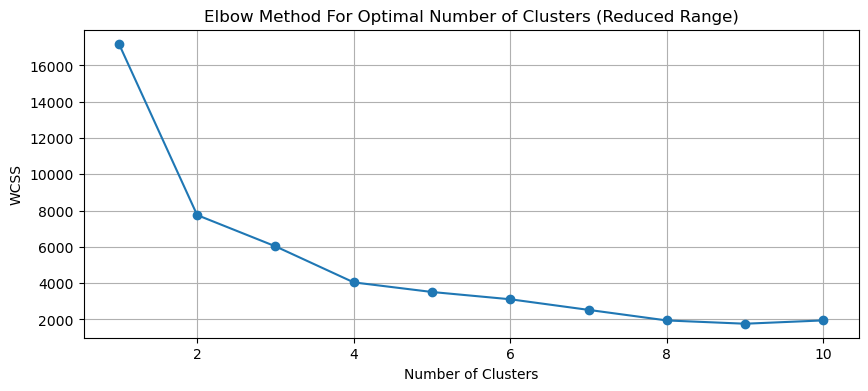

In [101]:
plt.figure(figsize=(10,4))
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.plot(range(1,11),wcs_reduced,marker='o',linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True);

In [102]:
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(transformed_amenities)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(transformed_amenities)

In [103]:
cluster_assignments

array([1, 1, 1, ..., 0, 1, 0], shape=(2866,), dtype=int32)

In [104]:
df['luxury_type'] = cluster_assignments

In [105]:
with pd.option_context('display.max_colwidth', None):
    display(df[['Amenities: Main Features','luxury_type']].sample(10)) 

,Amenities: Main Features,luxury_type
130,"Built in year: 2021, Parking Spaces: 2, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features, Furnished",1
2735,"Built in year: 2000, Parking Spaces: 10, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Furnished",1
1375,"Built in year: 2022, Parking Spaces, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features, Furnished",1
52,"Built in year: 2025, Parking Spaces, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features",1
2844,"Built in year, Parking Spaces, Flooring, Electricity Backup, Floor, Floors in Building: 9, Elevators",0
1639,"Built in year: 2025, Parking Spaces: 11, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 2, Other Main Features, Furnished",1
663,NaN,0
1145,"Built in year: 2024, Parking Spaces: 15, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floors: 3, Other Main Features, Furnished",1
970,"Built in year: 2025, Parking Spaces: 22, Double Glazed Windows, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Waste Disposal, Floor: 2, Floors in Building: 10, Elevators: 2, Service Elevators in Building, Other Main Features, Furnished",1
2419,"Built in year: 2026, Central Air Conditioning, Central Heating, Flooring, Electricity Backup, Floor: 3, Floors in Building: 21, Elevators: 8, Service Elevators in Building, Other Main Features",0


**From Observation:**
- **0 --> Luxury**
- **1 --> Budget**

In [106]:
df['luxury_type'].value_counts()

luxury_type
1    2283
0     583
Name: count, dtype: int64

In [107]:
main_amenities.head()

,Built in year,Parking Spaces,Double Glazed Windows,Central Air Conditioning,Central Heating,Flooring,Electricity Backup,Waste Disposal,Floor,Other Main Features,Furnished,Lobby in Building,Floor in Building,Elevators,Service Elevators in Building
0,1.0,4.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
2,4.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0
3,2025.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0


In [108]:
main_amenities['Service Elevators in Building'].sum()

np.float64(478.0)

Appending the columns to original dataframe <i>'Built in year','Parking Spaces','Floor','Lobby in Building','Elevators','Service Elevators in Building' </i>

In [109]:
df = pd.concat((df,main_amenities[['Built in year','Parking Spaces','Floor','Lobby in Building','Elevators','Service Elevators in Building']]),axis=1)

In [110]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 26 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

### Amenities: Rooms

In [111]:
df['Amenities: Rooms'].loc[0]

'Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2, Drawing Room, Dining Room, Kitchens: 2, Study Room, Prayer Room, Powder Room, Gym, Store Rooms: 1, Steam Room, Lounge or Sitting Room, Laundry Room, Other Rooms'

In [112]:
def extract_rooms(series):
    if pd.isna(series):
        return {}
    
    rooms_dic = {}

    room_lst = series.split(',')

    for room in room_lst:
        room.replace(' ','')
        colon_pos = room.find(':')
        if colon_pos == -1:
            room_name = room.strip()
            room_no = 0
        else:
            room_name = room[:colon_pos]
            room_no = room[colon_pos+1:]
            room_no = int(room_no.strip())

        rooms_dic[room_name] = room_no

    return rooms_dic

In [113]:
parsed_rooms = df['Amenities: Rooms'].str.replace(', ',',').apply(extract_rooms)

In [114]:
rooms = pd.DataFrame(parsed_rooms.tolist(),index=df.index)

In [115]:
rooms.describe()

,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Gym,Store Rooms,Steam Room,Lounge or Sitting Room,Laundry Room,Other Rooms
count,2515.000000,2520.000000,2145.000000,2509.0,2472.0,2513.000000,2081.0,2035.0,2141.0,1687.0,2093.000000,1832.0,2320.0,2197.0,1718.0
mean,4.272763,4.839286,1.210256,0.0,0.0,1.551134,0.0,0.0,0.0,0.0,1.085523,0.0,0.0,0.0,0.0
std,2.097929,2.630622,0.974051,0.0,0.0,0.872364,0.0,0.0,0.0,0.0,0.681527,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
25%,3.000000,3.000000,1.000000,0.0,0.0,1.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
50%,4.000000,5.000000,1.000000,0.0,0.0,2.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
75%,5.000000,6.000000,2.000000,0.0,0.0,2.000000,0.0,0.0,0.0,0.0,1.000000,0.0,0.0,0.0,0.0
max,22.000000,62.000000,22.000000,0.0,0.0,22.000000,0.0,0.0,0.0,0.0,10.000000,0.0,0.0,0.0,0.0


In [116]:
rooms.head()

,Bedrooms,Bathrooms,Servant Quarters,Drawing Room,Dining Room,Kitchens,Study Room,Prayer Room,Powder Room,Gym,Store Rooms,Steam Room,Lounge or Sitting Room,Laundry Room,Other Rooms
0,6.0,8.0,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,3.0,5.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,5.0,6.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,3.0,4.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
4,3.0,3.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [117]:
rooms['Bathrooms'].value_counts()

Bathrooms
6.0     583
5.0     368
2.0     302
4.0     279
3.0     273
7.0     272
1.0     150
8.0     128
9.0      52
0.0      50
10.0     33
12.0     10
11.0      7
16.0      6
13.0      3
17.0      2
14.0      1
62.0      1
Name: count, dtype: int64

In [118]:
rooms['Lounge or Sitting Room'].value_counts()

Lounge or Sitting Room
0.0    2320
Name: count, dtype: int64

In [119]:
rooms.drop(columns=['Drawing Room','Dining Room','Study Room','Prayer Room','Powder Room','Gym','Steam Room','Other Rooms','Lounge or Sitting Room','Laundry Room'],inplace=True)

In [120]:
rooms.head()

,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms
0,6.0,8.0,2.0,2.0,1.0
1,3.0,5.0,1.0,1.0,1.0
2,5.0,6.0,1.0,2.0,1.0
3,3.0,4.0,1.0,2.0,2.0
4,3.0,3.0,2.0,1.0,1.0


In [121]:
rooms.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Bedrooms          2515 non-null   float64
 1   Bathrooms         2520 non-null   float64
 2   Servant Quarters  2145 non-null   float64
 3   Kitchens          2513 non-null   float64
 4   Store Rooms       2093 non-null   float64
dtypes: float64(5)
memory usage: 198.9 KB


In [122]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 26 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

In [123]:
rooms.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879],
      dtype='int64', length=2866)

In [124]:
df = pd.concat((df,rooms),axis=1)

In [125]:
df.head(2)

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,...,Parking Spaces,Floor,Lobby in Building,Elevators,Service Elevators in Building,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms
0,House,12.0,7,10.0,6,D-12,NaN,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,4.0,2.0,0.0,0.0,0.0,6.0,8.0,2.0,2.0,1.0
1,House,4.3,5,4.4,3,D-12,D-12/4,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,2.0,0.0,0.0,0.0,3.0,5.0,1.0,1.0,1.0


In [126]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Location Details', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms'],
      dtype='str')

### Amenities: Business and Communication

In [127]:
df['Amenities: Business and Communication'].value_counts()

Amenities: Business and Communication
Broadband Internet Access, Satellite or Cable TV Ready, Intercom, Other Business and Communication Facilities                                                                                          1404
Broadband Internet Access, Satellite or Cable TV Ready, Intercom                                                                                                                                        363
Broadband Internet Access, Satellite or Cable TV Ready, Business Center or Media Room in Building, Conference Room in Building, Intercom, ATM Machines, Other Business and Communication Facilities     296
Broadband Internet Access, Satellite or Cable TV Ready                                                                                                                                                  121
Broadband Internet Access, Satellite or Cable TV Ready, Other Business and Communication Facilities                                               

In [128]:
set(df['Amenities: Business and Communication'].dropna().str.split(', ').sum())

{'ATM Machines',
 'Broadband Internet Access',
 'Business Center or Media Room in Building',
 'Conference Room in Building',
 'Intercom',
 'Other Business and Communication Facilities',
 'Satellite or Cable TV Ready'}

In [129]:
def extract_business_and_com(series):
    if pd.isna(series):
        return {}
    
    dic = {'ATM Machines':0,
     'Broadband Internet Access':0,
     'Business Center or Media Room in Building':0,
     'Conference Room in Building':0,
     'Intercom':0,
     'Other Business and Communication Facilities':0,
     'Satellite or Cable TV Ready':0}

    lst = series.split(', ')

    for i in lst:
        dic[i] = 1

    return dic

In [130]:
parsed_bus_com = df['Amenities: Business and Communication'].apply(extract_business_and_com)

In [131]:
bus_com = pd.DataFrame(parsed_bus_com.tolist(),index=df.index)

In [132]:
bus_com.describe()

,ATM Machines,Broadband Internet Access,Business Center or Media Room in Building,Conference Room in Building,Intercom,Other Business and Communication Facilities,Satellite or Cable TV Ready
count,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000
mean,0.169714,0.984897,0.162957,0.163355,0.880366,0.751590,0.967806
std,0.375456,0.121988,0.369400,0.369762,0.324598,0.432177,0.176550
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [133]:
bus_com.drop(columns=['Broadband Internet Access','Intercom','Other Business and Communication Facilities','Satellite or Cable TV Ready'],inplace=True)

In [134]:
bus_com.head()

,ATM Machines,Business Center or Media Room in Building,Conference Room in Building
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0
3,0.0,0.0,0.0
4,0.0,0.0,0.0


In [135]:
bus_com.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 3 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   ATM Machines                               2516 non-null   float64
 1   Business Center or Media Room in Building  2516 non-null   float64
 2   Conference Room in Building                2516 non-null   float64
dtypes: float64(3)
memory usage: 154.1 KB


In [136]:
rooms.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Bedrooms          2515 non-null   float64
 1   Bathrooms         2520 non-null   float64
 2   Servant Quarters  2145 non-null   float64
 3   Kitchens          2513 non-null   float64
 4   Store Rooms       2093 non-null   float64
dtypes: float64(5)
memory usage: 198.9 KB


In [137]:
df.tail()

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,...,Parking Spaces,Floor,Lobby in Building,Elevators,Service Elevators in Building,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms
2875,House,0.83,2,5.0,2,DHA Defence,NaN,On a quest to find something remarkable in Isl...,"Parking Spaces: 2, Double Glazed Windows, Floo...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...",...,2.0,0.0,0.0,0.0,0.0,4.0,5.0,1.0,2.0,1.0
2876,House,0.75,2,5.0,2,DHA Defence,NaN,House no 18 street 75 sector oleander block D ...,"Waste Disposal, Other Main Features",NaN,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2877,House,2.40,6,5.0,5,H-13,H-13,H-13 Paris City F-Block 5 Marla 2.5 story Hous...,NaN,"Bedrooms: 5, Bathrooms: 6, Drawing Room, Dinin...",...,0.0,0.0,0.0,0.0,0.0,5.0,6.0,NaN,3.0,NaN
2878,House,7.90,5,8.0,5,E-11,E-11/2,Details: E-11/2 Near to Markaz Size 30-60.8 Ma...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 5, Bathrooms: 5, Servant Quarters, D...",...,1.0,2.0,0.0,0.0,0.0,5.0,5.0,0.0,2.0,0.0
2879,House,16.00,-,22.0,-,G-11,NaN,Kanal+ Big and Elegant House is available for ...,"Built in year: 2025, Parking Spaces: 6, Floori...","Bedrooms: 14, Bathrooms: 16, Servant Quarters:...",...,6.0,3.0,0.0,0.0,0.0,14.0,16.0,3.0,6.0,2.0


In [138]:
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879],
      dtype='int64', length=2866)

In [139]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 31 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

In [140]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Location Details', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms'],
      dtype='str')

### Amenities: Community Features

In [141]:
set(df['Amenities: Community Features'].dropna().str.split(', ').sum())

{'Barbeque Area',
 'Community Centre',
 'Community Gym',
 'Community Lawn or Garden',
 'Community Swimming Pool',
 'Day Care Centre',
 'First Aid or Medical Centre',
 'Kids Play Area',
 'Mosque',
 'Other Community Facilities'}

In [142]:
df['Amenities: Community Features'].loc[0]

'Community Lawn or Garden, Community Swimming Pool, Community Gym, First Aid or Medical Centre, Day Care Centre, Kids Play Area, Barbeque Area, Mosque, Community Centre, Other Community Facilities'

In [143]:
import pandas as pd

# 1. Recreating a sample dataset based on your community features
data = {
    'ID': [801, 802, 803],
    'Community_Features': [
        'Community Lawn or Garden, Community Swimming Pool, Community Gym, Day Care Centre',
        'Mosque, Kids Play Area, Barbeque Area',
        'Community Gym, First Aid or Medical Centre, Other Community Facilities'
    ]
}
temp = pd.DataFrame(data)

# 2. Function to parse the comma-separated string into a dictionary
def extract_community_amenities(feature_string):
    # If the row is empty (NaN), return an empty dictionary
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    
    # Split the string by commas
    items = feature_string.split(',')
    
    for item in items:
        # Strip leading/trailing spaces to keep column names clean
        item = item.strip()
        if not item:
            continue
            
        # Since these are just text features without counts, we simply assign a 1
        amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function to the text column
parsed_community = temp['Community_Features'].apply(extract_community_amenities)

# 4. Convert the dictionaries into the wide grid format
grid_temp = pd.DataFrame(parsed_community.tolist())

# 5. Fill all missing values with 0 and convert the grid to integers
grid_temp = grid_temp.fillna(0).astype(int)

# 6. Merge the original IDs back onto the grid so you don't lose track of your rows
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Community Lawn or Garden,Community Swimming Pool,Community Gym,Day Care Centre,Mosque,Kids Play Area,Barbeque Area,First Aid or Medical Centre,Other Community Facilities
0,801,1,1,1,1,0,0,0,0,0
1,802,0,0,0,0,1,1,1,0,0
2,803,0,0,1,0,0,0,0,1,1


In [144]:
parsed_community = df['Amenities: Community Features'].apply(extract_community_amenities)

In [145]:
communities_amen = pd.DataFrame(parsed_community.tolist(),index=df.index)

In [146]:
communities_amen.head()

,Community Lawn or Garden,Community Swimming Pool,Community Gym,First Aid or Medical Centre,Day Care Centre,Kids Play Area,Barbeque Area,Mosque,Community Centre,Other Community Facilities
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [147]:
communities_amen.columns

Index(['Community Lawn or Garden', 'Community Swimming Pool', 'Community Gym',
       'First Aid or Medical Centre', 'Day Care Centre', 'Kids Play Area',
       'Barbeque Area', 'Mosque', 'Community Centre',
       'Other Community Facilities'],
      dtype='str')

In [148]:
communities_amen.drop(columns=['Community Lawn or Garden', 
       'First Aid or Medical Centre', 'Day Care Centre', 'Kids Play Area',
       'Barbeque Area', 'Mosque', 'Community Centre',
       'Other Community Facilities'],inplace=True)

In [149]:
communities_amen.head()

,Community Swimming Pool,Community Gym
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0


In [150]:
df = pd.concat((df,communities_amen),axis=1)

In [151]:
df.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       2870, 2871, 2872, 2873, 2874, 2875, 2876, 2877, 2878, 2879],
      dtype='int64', length=2866)

### Amenities: Healthcare Recreational

In [152]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Location Details', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Nearby Locations and Other Facilities',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym'],
      dtype='str')

In [153]:
set(df['Amenities: Healthcare Recreational'].dropna().str.split(', ').sum())

{'Jacuzzi',
 'Lawn or Garden',
 'Other Healthcare and Recreation Facilities',
 'Sauna',
 'Swimming Pool'}

In [154]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 33 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

In [155]:
import pandas as pd

# 1. Sample dataset based on your amenities
data = {
    'ID': [501, 502, 503],
    'Healthcare_Recreational': [
        'Swimming Pool, Jacuzzi, Lawn or Garden',
        'Lawn or Garden, Other Healthcare and Recreation Facilities',
        'Sauna, Swimming Pool'
    ]
}
temp = pd.DataFrame(data)

# 2. Define the exact features we ACTUALLY care about
target_features = ['Swimming Pool', 'Jacuzzi', 'Sauna']

def extract_luxury_recreation(feature_string):
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    items = feature_string.split(',')
    
    for item in items:
        item = item.strip()
        
        # ONLY add it to the dictionary if it's one of our target luxury features!
        if item in target_features:
            amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function
parsed_recreation = temp['Healthcare_Recreational'].apply(extract_luxury_recreation)

# 4. Create the grid
grid_temp = pd.DataFrame(parsed_recreation.tolist())

# 5. Ensure all target columns exist (even if no row had a Sauna, we want the column for consistency)
for feature in target_features:
    if feature not in grid_temp.columns:
        grid_temp[feature] = 0

# 6. Fill missing values with 0 and format as integers
grid_temp = grid_temp.fillna(0).astype(int)

# 7. Merge back with the IDs
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Swimming Pool,Jacuzzi,Sauna
0,501,1,1,0
1,502,0,0,0
2,503,1,0,1


In [156]:
parsed_healthcare = df['Amenities: Healthcare Recreational'].apply(extract_luxury_recreation)

In [157]:
healthcare_amen = pd.DataFrame(parsed_healthcare.tolist(),index=df.index)

In [158]:
healthcare_amen.head()

,Swimming Pool,Sauna,Jacuzzi
0,1.0,1.0,1.0
1,1.0,1.0,1.0
2,1.0,1.0,1.0
3,1.0,1.0,1.0
4,1.0,1.0,1.0


In [159]:
healthcare_amen.sum()

Swimming Pool    1109.0
Sauna            1806.0
Jacuzzi          1815.0
dtype: float64

In [160]:
df = pd.concat((df,healthcare_amen),axis=1)

In [161]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 36 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Type                                              2866 non-null   str    
 1   Price(Cr)                                         2866 non-null   float64
 2   Bath(s)                                           2866 non-null   str    
 3   Area(Marla)                                       2866 non-null   float64
 4   Bedroom(s)                                        2866 non-null   str    
 5   Location                                          2866 non-null   str    
 6   Location Details                                  878 non-null    str    
 7   Description                                       2866 non-null   str    
 8   Amenities: Main Features                          2683 non-null   str    
 9   Amenities: Rooms                   

In [162]:
df.sample(5)

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,...,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi
2663,House,2.38,3,5.0,3,Bahria Town,NaN,Bahria Enclave Islamabad 5 Marla brand new hou...,"Parking Spaces, Double Glazed Windows, Central...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 1...",...,3.0,3.0,1.0,1.0,NaN,1.0,1.0,NaN,NaN,NaN
2211,House,2.50,-,7.0,7,E-16,E-16/3,7 Marla House for Sale in E-16/3 Prime Locatio...,NaN,"Bedrooms: 7, Bathrooms: 7, Drawing Room, Dinin...",...,7.0,7.0,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2389,House,18.00,6,30.0,6,DHA Defence,NaN,Dha2 1.5 kanal FULL FURNISHED House prime loca...,"Built in year: 2024, Parking Spaces: 4, Double...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,6.0,8.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0
2181,House,7.50,7,20.0,7,Top City 1,NaN,Designer House In Top City Prime Location 7 Be...,"Built in year: 2024, Parking Spaces: 2, Double...","Bedrooms: 7, Bathrooms: 8, Servant Quarters: 1...",...,7.0,8.0,1.0,2.0,2.0,NaN,1.0,NaN,NaN,NaN
582,House,3.15,5,4.0,5,I-11,I-11/2,Brand New Double Story Extra Land House Is Ava...,"Built in year: 2025, Parking Spaces: 1, Double...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 1...",...,5.0,5.0,1.0,2.0,NaN,1.0,1.0,1.0,1.0,1.0


### Amenities: Nearby Locations and Other Facilities

In [163]:
df['Amenities: Nearby Locations and Other Facilities'].loc[0]

'Nearby Schools, Nearby Hospitals, Nearby Shopping Malls, Nearby Restaurants, Distance From Airport (kms), Nearby Public Transport Service, Other Nearby Places'

In [164]:
set(df['Amenities: Nearby Locations and Other Facilities'].dropna().str.split(', ').sum())

{'Distance From Airport (kms)',
 'Nearby Hospitals',
 'Nearby Public Transport Service',
 'Nearby Restaurants',
 'Nearby Schools',
 'Nearby Shopping Malls',
 'Other Nearby Places'}

In [165]:
import pandas as pd
import re

# 1. Sample data covering different ways brokers might type the distance
data = {
    'ID': [901, 902, 903, 904],
    'Nearby_Locations': [
        'Nearby Hospitals, Distance From Airport (kms): 35.5, Nearby Schools',
        'Nearby Restaurants, Distance From Airport: 12, Nearby Shopping Malls',
        'Distance From Airport (kms) 8.2, Other Nearby Places',
        'Nearby Public Transport Service, Nearby Schools' # Trap: Missing airport distance entirely
    ]
}
temp = pd.DataFrame(data)

# 2. Function to extract ONLY the airport distance
def extract_airport_distance(location_string):
    if pd.isna(location_string):
        return None
    
    # --- THE REGEX PATTERN ---
    # (?i) : Ignore case
    # Distance From Airport : The anchor phrase
    # .*? : Skips any junk characters in between (like " (kms): " or " : ")
    # (\d+(?:\.\d+)?) : Captures the actual number, including decimals if they exist
    match = re.search(r'(?i)Distance From Airport.*?(\d+(?:\.\d+)?)', location_string)
    
    if match:
        # Convert the extracted string number into a mathematical float
        return float(match.group(1))
    else:
        # If the broker didn't mention it, return None (NaN) so we don't assume 0 km!
        return None

# 3. Apply the function to create a brand new, clean numerical column
temp['Airport_Distance_km'] = temp['Nearby_Locations'].apply(extract_airport_distance)

(temp[['ID', 'Nearby_Locations', 'Airport_Distance_km']])

,ID,Nearby_Locations,Airport_Distance_km
0,901,"Nearby Hospitals, Distance From Airport (kms):...",35.5
1,902,"Nearby Restaurants, Distance From Airport: 12,...",12.0
2,903,"Distance From Airport (kms) 8.2, Other Nearby ...",8.2
3,904,"Nearby Public Transport Service, Nearby Schools",NaN


In [166]:
df.drop(columns=['Amenities: Nearby Locations and Other Facilities'],inplace=True)

In [167]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Location Details', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym', 'Swimming Pool', 'Sauna',
       'Jacuzzi'],
      dtype='str')

### Amenities: Other Facilities

In [168]:
df['Amenities: Other Facilities'].loc[0]

'Security Staff, Other Facilities'

In [169]:
set(df['Amenities: Other Facilities'].dropna().str.split(', ').sum())

{'Communal/Shared Kitchen',
 'Facilities for Disabled',
 'Laundry or Dry Cleaning Facility',
 'Maintenance Staff',
 'Other Facilities',
 'Pets Allowed',
 'Pets Not Allowed',
 'Security Staff'}

In [170]:
import pandas as pd

# 1. Sample data based on your column
data = {
    'ID': [601, 602, 603],
    'Amenities_Other': [
        'Security Staff, Maintenance Staff, Pets Allowed',
        'Communal/Shared Kitchen, Other Facilities',
        'Facilities for Disabled, Laundry or Dry Cleaning Facility, Security Staff'
    ]
}
temp = pd.DataFrame(data)

# 2. Define ONLY the features that actually impact price
price_features = [
    'Security Staff', 
    'Maintenance Staff', 
    'Communal/Shared Kitchen', 
    'Facilities for Disabled', 
    'Laundry or Dry Cleaning Facility'
]

def extract_other_facilities(feature_string):
    if pd.isna(feature_string):
        return {}
    
    amenity_dict = {}
    items = feature_string.split(',')
    
    for item in items:
        item = item.strip()
        
        # Only extract it if it has predictive power for price
        if item in price_features:
            amenity_dict[item] = 1
            
    return amenity_dict

# 3. Apply the function
parsed_other = temp['Amenities_Other'].apply(extract_other_facilities)

# 4. Create the grid
grid_temp = pd.DataFrame(parsed_other.tolist())

# 5. Ensure all target columns exist in the grid
for feature in price_features:
    if feature not in grid_temp.columns:
        grid_temp[feature] = 0

# 6. Fill NaNs with 0 and convert to integers
grid_temp = grid_temp.fillna(0).astype(int)

# 7. Merge back with your IDs
final_temp = pd.concat([temp[['ID']], grid_temp], axis=1)

(final_temp)

,ID,Security Staff,Maintenance Staff,Communal/Shared Kitchen,Facilities for Disabled,Laundry or Dry Cleaning Facility
0,601,1,1,0,0,0
1,602,0,0,1,0,0
2,603,1,0,0,1,1


In [171]:
parsed_other_fac =  df['Amenities: Other Facilities'].apply(extract_other_facilities)

In [172]:
other_facilites = pd.DataFrame(parsed_other_fac.tolist(),index=df.index)

In [173]:
other_facilites.head()

,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,1.0,NaN,NaN,NaN,NaN
1,1.0,NaN,NaN,NaN,NaN
2,1.0,1.0,1.0,NaN,NaN
3,1.0,1.0,1.0,NaN,NaN
4,1.0,1.0,1.0,NaN,NaN


In [174]:
other_facilites.sum()

Security Staff                      2473.0
Maintenance Staff                   2074.0
Facilities for Disabled             1789.0
Laundry or Dry Cleaning Facility     317.0
Communal/Shared Kitchen              226.0
dtype: float64

In [175]:
df = pd.concat((df,other_facilites),axis=1)

In [176]:
df.head()

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Location Details,Description,Amenities: Main Features,Amenities: Rooms,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,House,12.00,7,10.0,6,D-12,NaN,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,House,4.30,5,4.4,3,D-12,D-12/4,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,House,5.75,6,5.0,5,D-12,D-12/1,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
3,House,2.70,4,5.0,3,Bahria Town,NaN,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
4,House,3.00,6,7.0,5,Jinnah Garden,NaN,Now We Found A Beautiful And Luxury House In J...,"Built in year, Parking Spaces, Double Glazed W...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 2...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [177]:
df.info()

<class 'pandas.DataFrame'>
Index: 2866 entries, 0 to 2879
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Type                                   2866 non-null   str    
 1   Price(Cr)                              2866 non-null   float64
 2   Bath(s)                                2866 non-null   str    
 3   Area(Marla)                            2866 non-null   float64
 4   Bedroom(s)                             2866 non-null   str    
 5   Location                               2866 non-null   str    
 6   Location Details                       878 non-null    str    
 7   Description                            2866 non-null   str    
 8   Amenities: Main Features               2683 non-null   str    
 9   Amenities: Rooms                       2622 non-null   str    
 10  Amenities: Business and Communication  2516 non-null   str    
 11  Amenities: Community

In [178]:
df[['Amenities: Main Features','Amenities: Rooms']].isnull().head()

,Amenities: Main Features,Amenities: Rooms
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False


In [179]:
df.to_csv('zameen_cleaned_v2.csv')

### Filling the information from Description 

In [180]:
df.columns

Index(['Type', 'Price(Cr)', 'Bath(s)', 'Area(Marla)', 'Bedroom(s)', 'Location',
       'Location Details', 'Description', 'Amenities: Main Features',
       'Amenities: Rooms', 'Amenities: Business and Communication',
       'Amenities: Community Features', 'Amenities: Healthcare Recreational',
       'Amenities: Other Facilities', 'IsPrimeLoc', 'SolarInstalled',
       'WaterBore', 'CornerHouse', 'luxury_type', 'Built in year',
       'Parking Spaces', 'Floor', 'Lobby in Building', 'Elevators',
       'Service Elevators in Building', 'Bedrooms', 'Bathrooms',
       'Servant Quarters', 'Kitchens', 'Store Rooms',
       'Community Swimming Pool', 'Community Gym', 'Swimming Pool', 'Sauna',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen'],
      dtype='str')

In [181]:
df[df['Location Details'].isnull()].index

Index([   0,    3,    4,    6,    7,    8,    9,   12,   16,   17,
       ...
       2863, 2864, 2865, 2867, 2868, 2869, 2872, 2875, 2876, 2879],
      dtype='int64', length=1988)

In [182]:
df['Description'].loc[4]

"Now We Found A Beautiful And Luxury House In Jinnah Garden For You In Very Reasonable Price. This House Is Located In Great Location. This House Has 6 Bathrooms And 5 Bedrooms. 7 Marla properties are best for investment as well as living purposes. House you've been looking for is available at the best price, so take action today. Let us help you in your search for a property in Islamabad. Looking to building a home in this city in the near future? Surely, there is no better location than Jinnah Gardens. For an affluent property, the price of Rs. 30000000 isn't much to ask. Buying this property will open up the options for you. You can either keep it as an investment or make the perfect home for your family. Be a proud owner of your own property today. For sound investment advice and options, call us!"

In [183]:
# There is some inconsistency that is some rows do not have the same Location and Location Details

In [184]:
# So Removing Location Details

In [185]:
df.drop(columns=['Location Details'],inplace = True)

In [186]:
df[df['Bathrooms']==62]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
1863,House,29.0,6,40.0,6,F-11,investor price house available for sale in f11...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 6, Bathrooms: 62, Servant Quarters: ...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,NaN,1.0,NaN,1.0,1.0,1.0,NaN,NaN


In [187]:
# Removing 'Bathrooms','Bedrooms' because it is already present in the data.

In [188]:
#df.drop(columns=['Bedrooms', 'Bathrooms'],inplace=True)

In [189]:
df[df['Kitchens']==df['Kitchens'].max()]

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
1211,House,35.0,-,40.0,7,F-10,house available for sale in f10 with 2 kanal e...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [190]:
df.loc[1211]

Type                                                                                 House
Price(Cr)                                                                             35.0
Bath(s)                                                                                  -
Area(Marla)                                                                           40.0
Bedroom(s)                                                                               7
Location                                                                              F-10
Description                              house available for sale in f10 with 2 kanal e...
Amenities: Main Features                 Built in year: 2024, Parking Spaces: 5, Double...
Amenities: Rooms                         Bedrooms: 7, Bathrooms: 7, Servant Quarters: 2...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features            Community Lawn or Garden, Community Swimming P...

In [191]:
df['Kitchens'].value_counts()

Kitchens
2.0     1253
1.0      934
0.0      192
3.0      110
4.0       16
5.0        5
22.0       1
11.0       1
6.0        1
Name: count, dtype: int64

In [192]:
df[df['Kitchens']>=4][['Type','Area(Marla)','Kitchens']]

,Type,Area(Marla),Kitchens
98,Flat,22.0,5.0
129,House,20.0,5.0
460,House,20.0,4.0
549,House,20.0,4.0
570,House,10.0,4.0
595,House,20.0,5.0
690,House,20.0,5.0
982,House,24.0,4.0
1010,House,20.0,4.0
1211,House,40.0,22.0


In [193]:
df['Description'].loc[690]

'Owner Built In House Size (45*90) 1) Beautiful Finishing 2) Digital Door Lock System Installed 3) Solid And Beautiful Doors 4) Beautiful Washrooms And Modern Designs Shower Set Installed 5) Modern Design Chandeliers And Lights Installed 6) Newly Trending Media Walls 7) AC*DC Fans Installed On Modern Design Selling 8) 2*4 Italian Tiles Installed On Flooring 9) Modern Designs Kitchens With Dirty Kitchens 10)3 To 4 Parking Space Huge Car Porch 11)Solid Construction 12)Beautiful And Clean Street 11)Best Location 13)Level and Pack House 14)Water Boring Available And Also Have Water Supply 15)All Facilities Available Near By 16)Servent Quarter With Kitchen 17)Built In Year 2025 October 18)Zero Km From Express Way'

In [194]:
df.loc[690]

Type                                                                                 House
Price(Cr)                                                                              6.1
Bath(s)                                                                                  6
Area(Marla)                                                                           20.0
Bedroom(s)                                                                              10
Location                                                                       Soan Garden
Description                              Owner Built In House Size (45*90) 1) Beautiful...
Amenities: Main Features                 Built in year: 2025, Parking Spaces: 4, Double...
Amenities: Rooms                         Bedrooms: 10, Bathrooms: 11, Servant Quarters:...
Amenities: Business and Communication    Broadband Internet Access, Satellite or Cable ...
Amenities: Community Features            Community Lawn or Garden, Community Swimming P...

In [207]:
df[df['Bath(s)']=='-']['Bathrooms'].value_counts().astype(str)

Bathrooms
7.0     24
6.0     20
8.0     16
4.0     12
5.0     10
9.0      9
3.0      7
10.0     7
2.0      7
12.0     4
11.0     3
1.0      1
16.0     1
Name: count, dtype: str

In [211]:
baths_idx = df[df['Bath(s)']=='-'].index
baths_idx

Index([ 148,  149,  211,  236,  243,  260,  337,  338,  367,  390,
       ...
       2809, 2813, 2821, 2846, 2852, 2857, 2863, 2867, 2870, 2879],
      dtype='int64', length=173)

In [219]:
baths_value = df[df['Bath(s)']=='-']['Bathrooms'].astype(str).values
baths_value

<ArrowStringArray>
[ '5.0', '12.0',    nan,  '7.0',  '6.0',  '5.0',    nan,  '4.0',  '4.0',
    nan,
 ...
  '6.0',    nan,  '5.0',  '3.0', '11.0',  '6.0',  '7.0',  '8.0',  '8.0',
 '16.0']
Length: 173, dtype: str

In [220]:
df.loc[baths_idx,'Bath(s)'] = baths_value

In [221]:
df['Bath(s)'].value_counts()

Bath(s)
6       955
5       412
2       318
4       288
3       269
7       235
1       213
7.0      24
6.0      20
8.0      16
4.0      12
5.0      10
9.0       9
3.0       7
10.0      7
2.0       7
12.0      4
11.0      3
10        2
1.0       1
9         1
16.0      1
Name: count, dtype: int64

In [224]:
baths_idx

Index([ 148,  149,  211,  236,  243,  260,  337,  338,  367,  390,
       ...
       2809, 2813, 2821, 2846, 2852, 2857, 2863, 2867, 2870, 2879],
      dtype='int64', length=173)

In [226]:
df.loc[baths_idx].head(3)

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
148,House,80.00,5.0,40.0,9,F-6,"Luxury House for Sale F-6/2, Islamabad Prime L...","Built in year: 2024, Parking Spaces, Double Gl...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 2...",NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN
149,House,130.00,12.0,100.0,10,F-6,A beautiful house available for sale in f/6 co...,"Built in year: 2020, Parking Spaces: 8, Centra...","Bedrooms: 10, Bathrooms: 12, Servant Quarters:...","Broadband Internet Access, Satellite or Cable ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
211,House,2.35,NaN,5.0,-,B-17,House prices can fluctuate but if you're ready...,"Double Glazed Windows, Central Air Conditionin...",NaN,"Broadband Internet Access, Satellite or Cable ...",...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN


In [228]:
# Bedrooms

In [230]:
bed_idx = df[df['Bedroom(s)']=='-'].index
bed_idx

Index([ 191,  211,  224,  243,  260,  266,  285,  324,  338,  363,
       ...
       2690, 2782, 2792, 2794, 2805, 2813, 2821, 2846, 2873, 2879],
      dtype='int64', length=145)

In [232]:
bed_value = df[df['Bedroom(s)']=='-']['Bedrooms'].astype(str).values
bed_value

<ArrowStringArray>
[ '3.0',    nan,  '1.0',  '5.0',  '4.0',  '1.0',  '1.0',  '1.0',  '3.0',
  '1.0',
 ...
    nan,  '3.0',  '1.0',  '2.0',  '1.0',    nan,  '4.0',  '3.0',  '3.0',
 '14.0']
Length: 145, dtype: str

In [233]:
df.loc[bed_idx,'Bedroom(s)'] = bed_value

In [234]:
df['Bedroom(s)'].value_counts()

Bedroom(s)
5       669
6       436
4       399
2       365
3       336
1       175
7       166
8        84
9        46
10       35
1.0      32
3.0      15
5.0      14
11       10
4.0       9
2.0       7
6.0       5
9.0       3
7.0       2
10.0      2
8.0       2
0.0       1
14.0      1
Name: count, dtype: int64

In [236]:
df.head()

,Type,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Location,Description,Amenities: Main Features,Amenities: Rooms,Amenities: Business and Communication,...,Community Swimming Pool,Community Gym,Swimming Pool,Sauna,Jacuzzi,Security Staff,Maintenance Staff,Facilities for Disabled,Laundry or Dry Cleaning Facility,Communal/Shared Kitchen
0,House,12.00,7,10.0,6,D-12,10 MARLA LUXXARY BRAND NEW PARK FACE AVAILABLE...,"Built in year, Parking Spaces: 4, Double Glaze...","Bedrooms: 6, Bathrooms: 8, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
1,House,4.30,5,4.4,3,D-12,4.44 Marla Single Unit Luxury House with Open ...,"Built in year, Parking Spaces: 1, Double Glaze...","Bedrooms: 3, Bathrooms: 5, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN
2,House,5.75,6,5.0,5,D-12,5 Marla Double Unit Front-Open 50 ft street Ho...,"Built in year: 4, Parking Spaces: 2, Double Gl...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
3,House,2.70,4,5.0,3,Bahria Town,Brand-New Designer House for Sale in Bahria En...,"Built in year: 2025, Parking Spaces, Double Gl...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN
4,House,3.00,6,7.0,5,Jinnah Garden,Now We Found A Beautiful And Luxury House In J...,"Built in year, Parking Spaces, Double Glazed W...","Bedrooms: 3, Bathrooms: 3, Servant Quarters: 2...","Broadband Internet Access, Satellite or Cable ...",...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN


In [237]:
df.to_csv('zameen_cleaned_v2.csv',index=False)